In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/meharbhanwra/robotics-rag-evaluation/robotics-rag-training-questions.csv


**PHASE 0: ENVIRONMENT SETUP**

In [2]:
import warnings

warnings.filterwarnings('ignore')

In [3]:
import sys
import torch

print("Python Version:", sys.version)
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Pandas Version:", pd.__version__)
print("NumPy Version:", np.__version__)

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch Version: 2.10.0+cpu
CUDA Available: False
Pandas Version: 2.3.3
NumPy Version: 2.4.6


In [4]:
!pip install -q \
langchain \
langchain-community \
sentence-transformers \
faiss-cpu \
transformers \
datasets \
evaluate \
bert-score \
rouge-score \
wikipedia-api \
rank-bm25

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 41.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 58.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.2/129.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 req

In [5]:
import faiss
import transformers
import sentence_transformers
import langchain
import wikipediaapi
import evaluate

print("Environment ready.")

Environment ready.


**PHASE 1: DATASET COLLECTION**

In [6]:
robotics_topics = [
    "Robotics",
    "Outline of robotics",
    "Robot locomotion",
    "Robotic Sensors",
    "Simultaneous localization and mapping",
    "Robot Operating System",
    "Autonomous robot",
    "Mobile robot",
    "Path planning",
    "Localization",
    "Sensor fusion",
    "Lidar",
    "Computer vision",
    "Kalman filter",
    "Reinforcement learning",
    "Humanoid robot",
    "Motion planning",
    "A* search algorithm",
    "Dijkstra's algorithm",
    "Monte Carlo localization"
]

In [7]:
print(robotics_topics)
print(f"Number of topics covered: {len(robotics_topics)}")

['Robotics', 'Outline of robotics', 'Robot locomotion', 'Robotic Sensors', 'Simultaneous localization and mapping', 'Robot Operating System', 'Autonomous robot', 'Mobile robot', 'Path planning', 'Localization', 'Sensor fusion', 'Lidar', 'Computer vision', 'Kalman filter', 'Reinforcement learning', 'Humanoid robot', 'Motion planning', 'A* search algorithm', "Dijkstra's algorithm", 'Monte Carlo localization']
Number of topics covered: 20


In [8]:
import wikipediaapi

wiki = wikipediaapi.Wikipedia(
    language='en',
    user_agent='robotics-rag-project'
)

for topic in robotics_topics:
    page = wiki.page(topic)
    print(f"{topic}: {'Found' if page.exists() else 'Missing'}")

Robotics: Found
Outline of robotics: Found
Robot locomotion: Found
Robotic Sensors: Found
Simultaneous localization and mapping: Found
Robot Operating System: Found
Autonomous robot: Found
Mobile robot: Found
Path planning: Found
Localization: Found
Sensor fusion: Found
Lidar: Found
Computer vision: Found
Kalman filter: Found
Reinforcement learning: Found
Humanoid robot: Found
Motion planning: Found
A* search algorithm: Found
Dijkstra's algorithm: Found
Monte Carlo localization: Found


In [9]:
import wikipediaapi
import pandas as pd

wiki = wikipediaapi.Wikipedia(
    language='en',
    user_agent='robotics-rag-project'
)

documents = []

for topic in robotics_topics:
    page = wiki.page(topic)

    if page.exists():
        documents.append({
            "title": page.title,
            "text": page.text
        })

df = pd.DataFrame(documents)

print(f"Documents collected: {len(df)}")
df.head()

Documents collected: 20


,title,text
0,Robotics,Robotics is the interdisciplinary study and pr...
1,Outline of robotics,The following outline is provided as an overvi...
2,Robot locomotion,Robot locomotion is the collective name for th...
3,Robotic sensors,Robotic sensors are used to estimate a robot's...
4,Simultaneous localization and mapping,Simultaneous localization and mapping (SLAM) i...


In [10]:
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

print("Number of Documents:", len(df))
print("Total Words:", df["word_count"].sum())
print("Average Words per Document:", round(df["word_count"].mean(), 2))
print("Largest Document:")
print(df.loc[df["word_count"].idxmax(), ["title", "word_count"]])

print("\nSmallest Document:")
print(df.loc[df["word_count"].idxmin(), ["title", "word_count"]])

Number of Documents: 20
Total Words: 82533
Average Words per Document: 4126.65
Largest Document:
title         Kalman filter
word_count            16752
Name: 13, dtype: object

Smallest Document:
title         Robotic sensors
word_count                405
Name: 3, dtype: object


In [11]:
for i in range(3):
    print("="*80)
    print(df.iloc[i]["title"])
    print("="*80)
    print(df.iloc[i]["text"][:1000])
    print("\n")

Robotics
Robotics is the interdisciplinary study and practice of the design, construction, operation, and use of robots. A roboticist is someone who specializes in robotics. Robotics usually combines four aspects of design work: a power source (e.g. a battery), mechanical construction, a control system (electrical circuits), and software (run by remote control or artificial intelligence).
The goal of most robotics is to design machines that can assist humans in various fields, such as agriculture, construction, domestic work, food processing, inventory management, manufacturing, medicine, military, mining, space exploration, and transportation.
Robots impact humans by displacing workers. Some expect this to occur at an increasing rate, leading to proposed solutions such as basic income. Robotics is itself a lucrative business that creates careers, especially for postgraduates. Roboticists often aim to create machines that seem to interface naturally with humans. The field is under acti

**PHASE 2: DATA CLEANING**

In [12]:
import re

def clean_text(text):
    text = re.sub(r'\[[0-9]+\]', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

In [13]:
df["raw_words"] = df["text"].apply(lambda x: len(x.split()))
df["clean_words"] = df["clean_text"].apply(lambda x: len(x.split()))

print("Words Before Cleaning:", df["raw_words"].sum())
print("Words After Cleaning:", df["clean_words"].sum())

print(
    "Words Removed:",
    df["raw_words"].sum() - df["clean_words"].sum()
)

Words Before Cleaning: 82533
Words After Cleaning: 82533
Words Removed: 0


In [14]:
df.to_csv("robotics_corpus.csv", index=False)

In [15]:
df["doc_id"] = range(len(df))

In [16]:
df.head()

,title,text,word_count,clean_text,raw_words,clean_words,doc_id
0,Robotics,Robotics is the interdisciplinary study and pr...,4928,Robotics is the interdisciplinary study and pr...,4928,4928,0
1,Outline of robotics,The following outline is provided as an overvi...,4927,The following outline is provided as an overvi...,4927,4927,1
2,Robot locomotion,Robot locomotion is the collective name for th...,2759,Robot locomotion is the collective name for th...,2759,2759,2
3,Robotic sensors,Robotic sensors are used to estimate a robot's...,405,Robotic sensors are used to estimate a robot's...,405,405,3
4,Simultaneous localization and mapping,Simultaneous localization and mapping (SLAM) i...,2639,Simultaneous localization and mapping (SLAM) i...,2639,2639,4


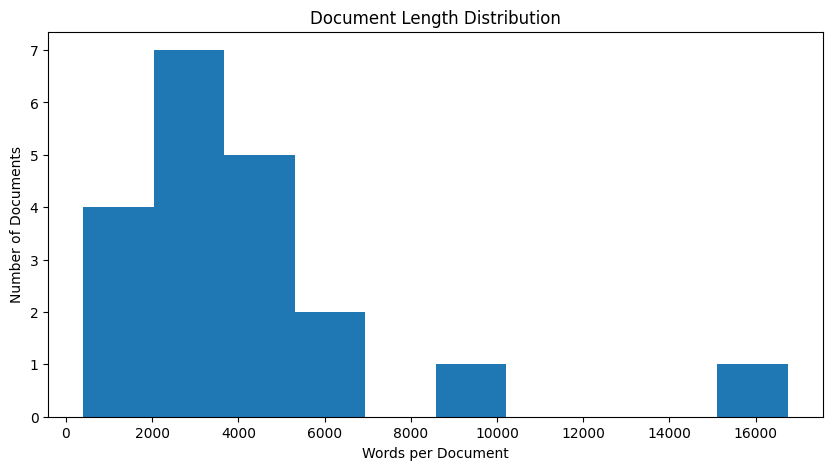

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["word_count"], bins=10)
plt.xlabel("Words per Document")
plt.ylabel("Number of Documents")
plt.title("Document Length Distribution")
plt.show()

**PHASE 3: CHUNKING**

In [18]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [19]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ".", " ", ""]
)

In [20]:
chunks = []

for _, row in df.iterrows():
    
    split_texts = text_splitter.split_text(row["clean_text"])
    
    for i, chunk in enumerate(split_texts):
        
        chunks.append({
            "doc_id": row["doc_id"],
            "title": row["title"],
            "chunk_id": f"{row['doc_id']}_{i}",
            "chunk_text": chunk
        })

chunk_df = pd.DataFrame(chunks)

print("Total Chunks:", len(chunk_df))

chunk_df.head()

Total Chunks: 681


,doc_id,title,chunk_id,chunk_text
0,0,Robotics,0_0,Robotics is the interdisciplinary study and pr...
1,0,Robotics,0_1,. Robotics is itself a lucrative business that...
2,0,Robotics,0_2,. Software: A program is how a robot decides w...
3,0,Robotics,0_3,". Additionally, a tether could connect the rob..."
4,0,Robotics,0_4,". Meanwhile, linear actuators move in and out ..."


In [21]:
chunk_df["chunk_length"] = chunk_df["chunk_text"].apply(len)

print("Total Chunks:", len(chunk_df))
print("Average Chunk Length:", round(chunk_df["chunk_length"].mean(), 2))
print("Minimum Chunk Length:", chunk_df["chunk_length"].min())
print("Maximum Chunk Length:", chunk_df["chunk_length"].max())

Total Chunks: 681
Average Chunk Length: 869.3
Minimum Chunk Length: 4
Maximum Chunk Length: 1000


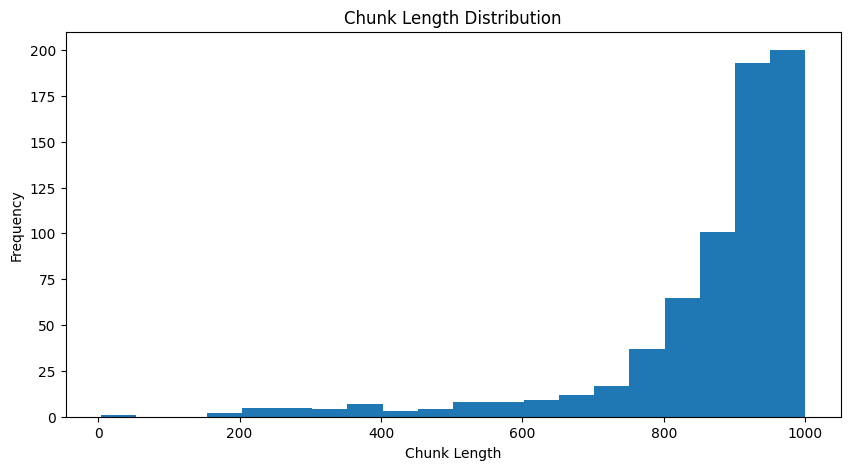

In [22]:
plt.figure(figsize=(10,5))
plt.hist(chunk_df["chunk_length"], bins=20)
plt.xlabel("Chunk Length")
plt.ylabel("Frequency")
plt.title("Chunk Length Distribution")
plt.show()

In [23]:
for i in range(3):
    print("="*80)
    print("TITLE:", chunk_df.iloc[i]["title"])
    print("CHUNK ID:", chunk_df.iloc[i]["chunk_id"])
    print("="*80)
    print(chunk_df.iloc[i]["chunk_text"])
    print("\n")

TITLE: Robotics
CHUNK ID: 0_0
Robotics is the interdisciplinary study and practice of the design, construction, operation, and use of robots. A roboticist is someone who specializes in robotics. Robotics usually combines four aspects of design work: a power source (e.g. a battery), mechanical construction, a control system (electrical circuits), and software (run by remote control or artificial intelligence). The goal of most robotics is to design machines that can assist humans in various fields, such as agriculture, construction, domestic work, food processing, inventory management, manufacturing, medicine, military, mining, space exploration, and transportation. Robots impact humans by displacing workers. Some expect this to occur at an increasing rate, leading to proposed solutions such as basic income. Robotics is itself a lucrative business that creates careers, especially for postgraduates. Roboticists often aim to create machines that seem to interface naturally with humans


T

In [24]:
chunk_df = chunk_df[
    chunk_df["chunk_text"].str.len() >= 100
].reset_index(drop=True)

print("Filtered Chunks:", len(chunk_df))

Filtered Chunks: 680


In [25]:
chunk_df["word_count"] = chunk_df["chunk_text"].apply(
    lambda x: len(x.split())
)

print(chunk_df["word_count"].describe())

count    680.000000
mean     138.213235
std       28.756304
min       24.000000
25%      127.000000
50%      142.000000
75%      153.000000
max      234.000000
Name: word_count, dtype: float64


In [26]:
chunk_df.to_csv(
    "robotics_chunks.csv",
    index=False
)

In [27]:
df.to_csv("robotics_corpus.csv", index=False)
chunk_df.to_csv("robotics_chunks.csv", index=False)

In [28]:
import pickle

with open("robotics_chunks.pkl", "wb") as f:
    pickle.dump(chunk_df, f)

**PHASE 4: EMBEDDINGS**

In [29]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [30]:
chunk_texts = chunk_df["chunk_text"].tolist()

embeddings = embedding_model.encode(
    chunk_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding Shape:", embeddings.shape)

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Embedding Shape: (680, 384)


In [31]:
print(type(embeddings))
print(embeddings.dtype)
print(embeddings[0][:10])

<class 'numpy.ndarray'>
float32
[-0.02448466 -0.01386263  0.014053   -0.0017483  -0.01776226 -0.10363616
  0.03619729  0.03788695 -0.03583167  0.0837689 ]


In [32]:
np.save(
    "robotics_embeddings.npy",
    embeddings
)

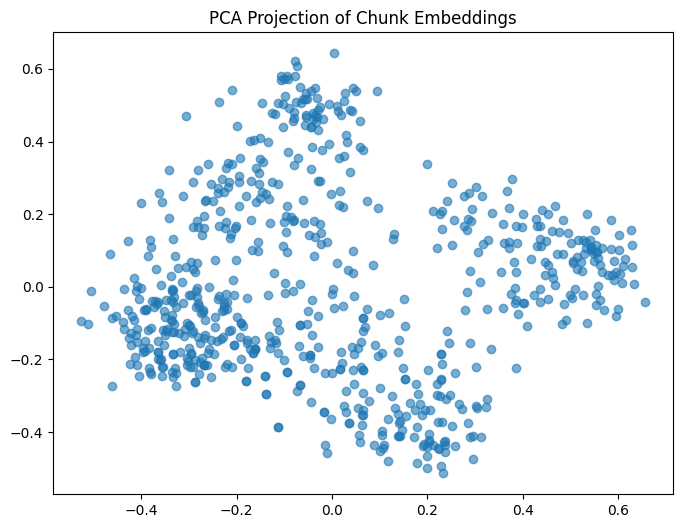

In [33]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    alpha=0.6
)

plt.title("PCA Projection of Chunk Embeddings")
plt.show()

In [34]:
import numpy as np

np.save("robotics_embeddings.npy", embeddings)

chunk_df.to_csv("robotics_chunks.csv", index=False)
df.to_csv("robotics_corpus.csv", index=False)

In [35]:
print(type(embeddings))
print(embeddings.shape)
print(embeddings.dtype)

<class 'numpy.ndarray'>
(680, 384)
float32


In [36]:
project_stats = {
    "documents": len(df),
    "chunks": len(chunk_df),
    "embedding_dimension": embeddings.shape[1],
    "embedding_model": "all-MiniLM-L6-v2"
}

print(project_stats)

{'documents': 20, 'chunks': 680, 'embedding_dimension': 384, 'embedding_model': 'all-MiniLM-L6-v2'}


In [37]:
import json

with open("project_stats.json", "w") as f:
    json.dump(project_stats, f, indent=4)

In [38]:
plt.savefig(
    "embedding_pca.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

**PHASE 5: VECTOR DATABASE**

In [39]:
import faiss
import numpy as np

dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print("FAISS Index Built")
print("Number of vectors:", index.ntotal)
print("Embedding dimension:", dimension)

FAISS Index Built
Number of vectors: 680
Embedding dimension: 384


In [40]:
faiss.write_index(
    index,
    "robotics_faiss.index"
)

In [41]:
def retrieve_chunks(
    query,
    embedding_model,
    index,
    chunk_df,
    top_k=5
):
    
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    ).astype("float32")
    
    distances, indices = index.search(
        query_embedding,
        top_k
    )
    
    results = []
    
    for rank, idx in enumerate(indices[0]):
        
        results.append({
            "rank": rank + 1,
            "distance": float(distances[0][rank]),
            "title": chunk_df.iloc[idx]["title"],
            "chunk_text": chunk_df.iloc[idx]["chunk_text"]
        })
    
    return results

In [42]:
def display_results(results):
    
    for result in results:
        
        print("=" * 100)
        print(f"Rank: {result['rank']}")
        print(f"Distance: {result['distance']:.4f}")
        print(f"Source: {result['title']}")
        print("-" * 100)
        print(result["chunk_text"][:700])
        print("\n")

In [43]:
query = "What is SLAM?"

results = retrieve_chunks(
    query,
    embedding_model,
    index,
    chunk_df,
    top_k=5
)

display_results(results)

Rank: 1
Distance: 0.8561
Source: Simultaneous localization and mapping
----------------------------------------------------------------------------------------------------
Simultaneous localization and mapping (SLAM) is a process where a computer constructs or updates a map of an unknown environment while simultaneously keeping track of an entity's location within it. While this initially appears to be a chicken or the egg problem, there are several algorithms known to solve it in, at least approximately, tractable time for certain environments. Popular approximate solution methods include the particle filter, extended Kalman filter, covariance intersection, and GraphSLAM. SLAM algorithms are based on concepts in computational geometry and computer vision, and are used in robot navigation, robotic mapping and odometry for virtual reality or augmented reality. 


Rank: 2
Distance: 0.8893
Source: Simultaneous localization and mapping
------------------------------------------------------

In [44]:
query = "What is ROS?"

results = retrieve_chunks(
    query,
    embedding_model,
    index,
    chunk_df,
    top_k=5
)

display_results(results)

Rank: 1
Distance: 0.8080
Source: Robot Operating System
----------------------------------------------------------------------------------------------------
. As such, there is very little which is core to ROS, beyond the general structure within which programs must exist and communicate. In one sense, ROS is the underlying plumbing behind nodes and message passing. However, in reality, ROS is not only plumbing, but a rich and mature set of tools, a wide-ranging set of robot-agnostic abilities provided by packages, and a greater ecosystem of additions to ROS. Computation graph model ROS processes are represented as nodes in a graph structure, connected by edges called topics. ROS nodes can pass messages to one another through topics, make service calls to other nodes, provide a service for other nodes, or set or retrieve shared data from a commu


Rank: 2
Distance: 0.8103
Source: Robot Operating System
------------------------------------------------------------------------------------

In [45]:
query = "How does LiDAR work?"

results = retrieve_chunks(
    query,
    embedding_model,
    index,
    chunk_df,
    top_k=5
)

display_results(results)

Rank: 1
Distance: 0.4721
Source: Lidar
----------------------------------------------------------------------------------------------------
Lidar (, an acronym of light detection and ranging or laser imaging, detection, and ranging, often stylized LiDAR) is a method for determining ranges by targeting an object or a surface with a laser and measuring the time for the reflected light to return to the receiver. Lidar may operate in a fixed direction (e.g., vertical) or it may scan directions, in a special combination of 3D scanning and laser scanning. Lidar has terrestrial, airborne, and mobile uses. It is commonly used to make high-resolution maps, with applications in surveying, geodesy, geomatics, archaeology, geography, geology, geomorphology, seismology, forestry, atmospheric physics, laser guidance, airborne laser swathe map


Rank: 2
Distance: 0.6137
Source: Lidar
----------------------------------------------------------------------------------------------------
. It is used to m

In [46]:
query = "How do robots determine their position in an unknown environment?"

results = retrieve_chunks(
    query,
    embedding_model,
    index,
    chunk_df,
    top_k=5
)

display_results(results)

Rank: 1
Distance: 0.6958
Source: Mobile robot
----------------------------------------------------------------------------------------------------
. Autonomously guided robot (AGR) An autonomously guided robot knows at least some information about where it is and how to reach various goals and or waypoints along the way. "Localization" or knowledge of its current location, is calculated by one or more means, using sensors such motor encoders, vision, Stereopsis, lasers and global positioning systems. Positioning systems often use triangulation, relative position and/or Monte-Carlo/Markov localization to determine the location and orientation of the platform, from which it can plan a path to its next waypoint or goal. It can gather sensor readings that are time- and location-stamped. Such robots are often part of the wireless enterprise


Rank: 2
Distance: 0.7052
Source: Monte Carlo localization
--------------------------------------------------------------------------------------------

In [47]:
query = "Which sensors are commonly used by autonomous robots for navigation?"

results = retrieve_chunks(
    query,
    embedding_model,
    index,
    chunk_df,
    top_k=5
)

display_results(results)

Rank: 1
Distance: 0.6764
Source: Computer vision
----------------------------------------------------------------------------------------------------
. In this case, automatic processing of the data is used to reduce complexity and to fuse information from multiple sensors to increase reliability. Autonomous vehicles One of the newer application areas is autonomous vehicles, which include submersibles, land-based vehicles (small robots with wheels, cars, or trucks), aerial vehicles, and unmanned aerial vehicles (UAV). The level of autonomy ranges from fully autonomous (unmanned) vehicles to vehicles where computer-vision-based systems support a driver or a pilot in various situations. Fully autonomous vehicles typically use computer vision for navigation, e.g., for knowing where they are or mapping their environment (SLAM), for detecting 


Rank: 2
Distance: 0.6861
Source: Autonomous robot
-------------------------------------------------------------------------------------------------

In [48]:
def retrieve_unique_documents(
    query,
    embedding_model,
    index,
    chunk_df,
    top_k=5,
    search_k=20
):
    
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    ).astype("float32")
    
    distances, indices = index.search(
        query_embedding,
        search_k
    )
    
    seen_titles = set()
    results = []
    
    for rank, idx in enumerate(indices[0]):
        
        title = chunk_df.iloc[idx]["title"]
        
        if title not in seen_titles:
            
            seen_titles.add(title)
            
            results.append({
                "title": title,
                "distance": float(distances[0][rank]),
                "chunk_text": chunk_df.iloc[idx]["chunk_text"]
            })
        
        if len(results) == top_k:
            break
    
    return results

**PHASE 6: RE-RANKING**

In [49]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2"
)

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [50]:
def retrieve_and_rerank(
    query,
    embedding_model,
    index,
    chunk_df,
    reranker,
    retrieve_k=30,
    final_k=3
):
    
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    ).astype("float32")
    
    distances, indices = index.search(
        query_embedding,
        retrieve_k
    )
    
    candidates = []
    
    pairs = []
    
    for idx in indices[0]:
        
        chunk_text = chunk_df.iloc[idx]["chunk_text"]
        
        pairs.append(
            [query, chunk_text]
        )
        
        candidates.append({
            "title": chunk_df.iloc[idx]["title"],
            "chunk_text": chunk_text
        })
    
    scores = reranker.predict(pairs)
    
    for i in range(len(candidates)):
        candidates[i]["rerank_score"] = float(scores[i])
    
    candidates = sorted(
        candidates,
        key=lambda x: x["rerank_score"],
        reverse=True
    )
    
    return candidates[:final_k]

In [51]:
def display_reranked(results):
    
    for rank, result in enumerate(results, start=1):
        
        print("=" * 100)
        print(f"Rank: {rank}")
        print(f"Score: {result['rerank_score']:.4f}")
        print(f"Source: {result['title']}")
        print("-" * 100)
        print(result["chunk_text"][:700])
        print("\n")

In [52]:
query = "What is ROS?"

results = retrieve_and_rerank(
    query,
    embedding_model,
    index,
    chunk_df,
    reranker
)

display_reranked(results)

Rank: 1
Score: 10.1048
Source: Robot Operating System
----------------------------------------------------------------------------------------------------
Robot Operating System (ROS or ros) is an open-source robotics middleware suite. Although ROS is not an operating system (OS) but a set of software frameworks for robot software development, it provides services designed for a heterogeneous computer cluster such as hardware abstraction, low-level device control, implementation of commonly used functionality, message-passing between processes, and package management. Running sets of ROS-based processes are represented in a graph architecture where processing takes place in nodes that may receive, post, and multiplex sensor data, control, state, planning, actuator, and other messages. Overview Despite the importance of reactivity and low laten


Rank: 2
Score: 8.1471
Source: Robot Operating System
-----------------------------------------------------------------------------------------

In [53]:
query = "Which sensors are commonly used by autonomous robots for navigation?"

results = retrieve_and_rerank(
    query,
    embedding_model,
    index,
    chunk_df,
    reranker
)

display_reranked(results)

Rank: 1
Score: 5.6902
Source: Autonomous robot
----------------------------------------------------------------------------------------------------
. The first commercial robots to achieve this were Pyxus' HelpMate hospital robot and the CyberMotion guard robot, both designed by robotics pioneers in the 1980s. These robots originally used manually created CAD floor plans, sonar sensing and wall-following variations to navigate buildings. The next generation, such as MobileRobots' PatrolBot and autonomous wheelchair, both introduced in 2004, have the ability to create their own laser-based maps of a building and to navigate open areas as well as corridors. Their control system changes its path on the fly if something blocks the way. At first, autonomous navigation was based on planar sensors, such as laser range-finders, that can only se


Rank: 2
Score: 5.6386
Source: Autonomous robot
----------------------------------------------------------------------------------------------------
.

In [54]:
query = "What is SLAM?"

results = retrieve_and_rerank(
    query,
    embedding_model,
    index,
    chunk_df,
    reranker
)

display_reranked(results)

Rank: 1
Score: 8.8151
Source: Simultaneous localization and mapping
----------------------------------------------------------------------------------------------------
Simultaneous localization and mapping (SLAM) is a process where a computer constructs or updates a map of an unknown environment while simultaneously keeping track of an entity's location within it. While this initially appears to be a chicken or the egg problem, there are several algorithms known to solve it in, at least approximately, tractable time for certain environments. Popular approximate solution methods include the particle filter, extended Kalman filter, covariance intersection, and GraphSLAM. SLAM algorithms are based on concepts in computational geometry and computer vision, and are used in robot navigation, robotic mapping and odometry for virtual reality or augmented reality. 


Rank: 2
Score: 5.2765
Source: Simultaneous localization and mapping
------------------------------------------------------------

In [55]:
evaluation_queries = [
    "What is SLAM?",
    "What is ROS?",
    "How does LiDAR work?",
    "How do robots determine their position?",
    "Which sensors are used for navigation?"
]

In [56]:
comparison_results = []

for query in evaluation_queries:

    # FAISS only
    faiss_results = retrieve_chunks(
        query,
        embedding_model,
        index,
        chunk_df,
        top_k=1
    )

    faiss_source = faiss_results[0]["title"]

    # Re-ranked
    reranked_results = retrieve_and_rerank(
        query,
        embedding_model,
        index,
        chunk_df,
        reranker,
        retrieve_k=30,
        final_k=1
    )

    reranked_source = reranked_results[0]["title"]

    comparison_results.append({
        "Query": query,
        "FAISS_Top1": faiss_source,
        "Reranked_Top1": reranked_source
    })

comparison_df = pd.DataFrame(comparison_results)

comparison_df

,Query,FAISS_Top1,Reranked_Top1
0,What is SLAM?,Simultaneous localization and mapping,Simultaneous localization and mapping
1,What is ROS?,Robot Operating System,Robot Operating System
2,How does LiDAR work?,Lidar,Lidar
3,How do robots determine their position?,Mobile robot,Monte Carlo localization
4,Which sensors are used for navigation?,Humanoid robot,Lidar


In [57]:
comparison_df.to_csv(
    "retrieval_comparison.csv",
    index=False
)

**PHASE 7: GENERATION**

In [58]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("FLAN-T5 Loaded Successfully")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

FLAN-T5 Loaded Successfully


In [59]:
def generate_text(
    prompt,
    max_new_tokens=150
):

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    )

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False
    )

    return tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

In [60]:
prompt = """
Question:
What is SLAM?

Answer:
"""

print(generate_text(prompt))

slang


In [61]:
def build_context(retrieved_chunks):

    contexts = []

    for chunk in retrieved_chunks:

        contexts.append(
            chunk["chunk_text"][:500]
        )

    return "\n\n".join(contexts)

In [62]:
def generate_answer(
    query,
    embedding_model,
    index,
    chunk_df,
    reranker,
    retrieve_k=30,
    final_k=3
):

    retrieved_chunks = retrieve_and_rerank(
        query=query,
        embedding_model=embedding_model,
        index=index,
        chunk_df=chunk_df,
        reranker=reranker,
        retrieve_k=retrieve_k,
        final_k=final_k
    )

    context = build_context(
        retrieved_chunks
    )

    prompt = f"""
    You are a robotics assistant.
    
    Answer the question using ONLY the provided context.
    
    Provide:
    1. A direct answer in the first sentence.
    2. Additional details afterwards.
    
    If the answer cannot be found in the context, respond exactly:
    
    I could not find the answer in the provided documents.
    
    Context:
    {context}
    
    Question:
    {query}
    
    Answer:
    """

    answer = generate_text(
        prompt,
        max_new_tokens=150
    )

    return {
        "question": query,
        "context": context,
        "answer": answer,
        "sources": [
            chunk["title"]
            for chunk in retrieved_chunks
        ]
    }

In [63]:
test_questions = [
    "What is SLAM?",
    "How does LiDAR work?",
    "What is the Robot Operating System?",
    "What is Monte Carlo Localization?",
    "What is sensor fusion?",
]

In [64]:
for question in test_questions:

    result = generate_answer(
        query=question,
        embedding_model=embedding_model,
        index=index,
        chunk_df=chunk_df,
        reranker=reranker
    )

    print("=" * 100)
    print("QUESTION:")
    print(result["question"])

    print("\nANSWER:")
    print(result["answer"])

    print("\n")

QUESTION:
What is SLAM?

ANSWER:
Simultaneous localization and mapping


QUESTION:
How does LiDAR work?

ANSWER:
determining ranges by targeting an object or a surface with a laser and measuring the time for the reflected light to return to the receiver


QUESTION:
What is the Robot Operating System?

ANSWER:
ROS or ros


QUESTION:
What is Monte Carlo Localization?

ANSWER:
an algorithm for robots to localize using a particle filter


QUESTION:
What is sensor fusion?

ANSWER:
a process of combining sensor data or data derived from disparate sources so that the resulting information has less uncertainty than would be possible if these sources were used individually




In [65]:
robotics_questions = [
                      'What is SLAM?', 
                      'What is ROS?', 
                      'What is LiDAR?', 
                      'What is Sensor Fusion?', 
                      'What is Monte Carlo Localization?', 
                      'What is Computer Vision?', 
                      'What is Path Planning?', 
                      'What is Reinforcement Learning?', 
                      'How does LiDAR work?', 
                      'How do mobile robots navigate?', 
                      'How do robots determine their position?', 
                      'How does SLAM work?', 
                      'How do autonomous robots avoid obstacles?', 
                      'How does sensor fusion improve robot perception?', 
                      'How does Monte Carlo Localization estimate position?', 
                      'What is the difference between localization and mapping?', 
                      'How is LiDAR different from computer vision?', 
                      'How is ROS different from a real-time operating system?', 
                      'What is the difference between autonomous and mobile robots?', 
                      'How does path planning differ from navigation?', 
                      'Why is SLAM important for robotics?', 
                      'Why is LiDAR useful for autonomous vehicles?', 
                      'Why is sensor fusion used in robotics?', 
                      'What are common sensors used in robots?', 
                      'Why is reinforcement learning useful in robotics?'
                     ]

In [66]:
results = []

for question in robotics_questions:

    result = generate_answer(
        query=question,
        embedding_model=embedding_model,
        index=index,
        chunk_df=chunk_df,
        reranker=reranker
    )

    results.append({
        "Question": result["question"],
        "Sources": ", ".join(result["sources"]),
        "Retrieved_Context": result["context"],
        "Answer": result["answer"]
    })

results_df = pd.DataFrame(results)

results_df

,Question,Sources,Retrieved_Context,Answer
0,What is SLAM?,"Simultaneous localization and mapping, Simulta...",Simultaneous localization and mapping (SLAM) i...,Simultaneous localization and mapping
1,What is ROS?,"Robot Operating System, Robot Operating System...",Robot Operating System (ROS or ros) is an open...,a set of software frameworks for robot softwar...
2,What is LiDAR?,"Lidar, Lidar, Lidar","Lidar (, an acronym of light detection and ran...",a method for determining ranges by targeting a...
3,What is Sensor Fusion?,"Sensor fusion, Sensor fusion, Sensor fusion",Sensor fusion is a process of combining sensor...,a process of combining sensor data or data der...
4,What is Monte Carlo Localization?,"Monte Carlo localization, Monte Carlo localiza...","Monte Carlo localization (MCL), also known as ...",an algorithm for robots to localize using a pa...
5,What is Computer Vision?,"Computer vision, Computer vision, Computer vision",". Image data can take many forms, such as vide...",The technological discipline of computer visio...
6,What is Path Planning?,"Motion planning, Motion planning, A* search al...","Motion planning, also path planning (also know...",a computational problem to find a sequence of ...
7,What is Reinforcement Learning?,"Reinforcement learning, Reinforcement learning...","In machine learning and optimal control, reinf...",Reinforcement learning is concerned with how a...
8,How does LiDAR work?,"Lidar, Lidar, Lidar","Lidar (, an acronym of light detection and ran...",determining ranges by targeting an object or a...
9,How do mobile robots navigate?,"Mobile robot, Mobile robot, Outline of robotics",A mobile robot is an automatic machine that is...,uncontrolled environment without the need for ...


In [67]:
results_df["Question"] = (
    results_df["Question"]
    .astype(str)
    .str.strip()
)

results_df

,Question,Sources,Retrieved_Context,Answer
0,What is SLAM?,"Simultaneous localization and mapping, Simulta...",Simultaneous localization and mapping (SLAM) i...,Simultaneous localization and mapping
1,What is ROS?,"Robot Operating System, Robot Operating System...",Robot Operating System (ROS or ros) is an open...,a set of software frameworks for robot softwar...
2,What is LiDAR?,"Lidar, Lidar, Lidar","Lidar (, an acronym of light detection and ran...",a method for determining ranges by targeting a...
3,What is Sensor Fusion?,"Sensor fusion, Sensor fusion, Sensor fusion",Sensor fusion is a process of combining sensor...,a process of combining sensor data or data der...
4,What is Monte Carlo Localization?,"Monte Carlo localization, Monte Carlo localiza...","Monte Carlo localization (MCL), also known as ...",an algorithm for robots to localize using a pa...
5,What is Computer Vision?,"Computer vision, Computer vision, Computer vision",". Image data can take many forms, such as vide...",The technological discipline of computer visio...
6,What is Path Planning?,"Motion planning, Motion planning, A* search al...","Motion planning, also path planning (also know...",a computational problem to find a sequence of ...
7,What is Reinforcement Learning?,"Reinforcement learning, Reinforcement learning...","In machine learning and optimal control, reinf...",Reinforcement learning is concerned with how a...
8,How does LiDAR work?,"Lidar, Lidar, Lidar","Lidar (, an acronym of light detection and ran...",determining ranges by targeting an object or a...
9,How do mobile robots navigate?,"Mobile robot, Mobile robot, Outline of robotics",A mobile robot is an automatic machine that is...,uncontrolled environment without the need for ...


In [68]:
results_df.to_csv(
    "rag_answers.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


**PHASE 8: EVALUATION DATASET**

In [69]:
import pandas as pd

file_path = "/kaggle/input/datasets/meharbhanwra/robotics-rag-evaluation/robotics-rag-training-questions.csv"

questions = []
ground_truths = []

with open(file_path, "r", encoding="latin1") as f:

    next(f)  # skip header

    for line in f:

        line = line.strip()

        if not line:
            continue

        question, answer = line.split(",", 1)

        questions.append(question.strip())
        ground_truths.append(answer.strip())

eval_df = pd.DataFrame({
    "question": questions,
    "ground_truth": ground_truths
})

eval_df["question"] = (
    eval_df["question"]
    .astype(str)
    .str.replace('\xa0', ' ', regex=False)
    .str.strip()
    .str.strip('"')
    .str.strip("'")
    .str.strip()
)

eval_df["ground_truth"] = (
    eval_df["ground_truth"]
    .astype(str)
    .str.replace('\xa0', ' ', regex=False)
    .str.strip()
    .str.strip('"')
    .str.strip("'")
    .str.strip()
    .str.replace('"""', '', regex=False)
)

print(eval_df.shape)
eval_df['ground_truth']

(25, 2)


0     Simultaneous localization and mapping (SLAM) i...
1     Robot Operating System (ROS or ros) is an open...
2     Lidar is a method for determining ranges by ta...
3     Sensor fusion is a process of combining sensor...
4     Monte Carlo localization (MCL), also known as ...
5     Computer vision tasks include methods for acqu...
6     Path planning or Motion planning(also known as...
7     In machine learning and optimal control, reinf...
8     LiDAR determining ranges by targeting an objec...
9     Mobile robots can be ""autonomous"" (AMR - aut...
10    Robots determine their position using localiza...
11    SLAM works by simultaneously building a map of...
12    Autonomous robots avoid obstacles by using sen...
13    Sensor fusion combines information from multip...
14    Monte Carlo Localization estimates a robot's p...
15    Localization determines a robot's position wit...
16    LiDAR measures distance by emitting laser puls...
17    ROS is an open-source robotics middleware 

In [70]:
print(eval_df.isnull().sum())

question        0
ground_truth    0
dtype: int64


In [71]:
print(eval_df.columns)

Index(['question', 'ground_truth'], dtype='object')


In [72]:
print("Number of Evaluation Questions:", len(eval_df))

Number of Evaluation Questions: 25


In [73]:
eval_df.columns = (
    eval_df.columns
    .str.strip()
    .str.lower()
)

eval_df.head()

,question,ground_truth
0,What is SLAM?,Simultaneous localization and mapping (SLAM) i...
1,What is ROS?,Robot Operating System (ROS or ros) is an open...
2,What is LiDAR?,Lidar is a method for determining ranges by ta...
3,What is Sensor Fusion?,Sensor fusion is a process of combining sensor...
4,What is Monte Carlo Localization?,"Monte Carlo localization (MCL), also known as ..."


In [74]:
evaluation_data = eval_df.to_dict(
    orient="records"
)

print(evaluation_data[:2])

[{'question': 'What is SLAM?', 'ground_truth': "Simultaneous localization and mapping (SLAM) is a process where a computer constructs or updates a map of an unknown environment while simultaneously keeping track of an entity's location within it."}, {'question': 'What is ROS?', 'ground_truth': 'Robot Operating System (ROS or ros) is an open-source robotics middleware suite.'}]


In [75]:
import json

evaluation_data = eval_df.to_dict(
    orient="records"
)

with open(
    "evaluation_dataset.json",
    "w"
) as f:

    json.dump(
        evaluation_data,
        f,
        indent=4
    )

print(evaluation_data[:2])

[{'question': 'What is SLAM?', 'ground_truth': "Simultaneous localization and mapping (SLAM) is a process where a computer constructs or updates a map of an unknown environment while simultaneously keeping track of an entity's location within it."}, {'question': 'What is ROS?', 'ground_truth': 'Robot Operating System (ROS or ros) is an open-source robotics middleware suite.'}]


In [76]:
eval_df.to_csv(
    "evaluation_dataset.csv",
    index=False
)

print("Evaluation CSV Saved")

Evaluation CSV Saved


In [77]:
question_set = list(eval_df['question'])

print(len(question_set))
print(question_set)

25
['What is SLAM?', 'What is ROS?', 'What is LiDAR?', 'What is Sensor Fusion?', 'What is Monte Carlo Localization?', 'What is Computer Vision?', 'What is Path Planning?', 'What is Reinforcement Learning?', 'How does LiDAR work?', 'How do mobile robots navigate?', 'How do robots determine their position?', 'How does SLAM work?', 'How do autonomous robots avoid obstacles?', 'How does sensor fusion improve robot perception?', 'How does Monte Carlo Localization estimate position?', 'What is the difference between localization and mapping?', 'How is LiDAR different from computer vision?', 'How is ROS different from a real-time operating system?', 'What is the difference between autonomous and mobile robots?', 'How does path planning differ from navigation?', 'Why is SLAM important for robotics?', 'Why is LiDAR useful for autonomous vehicles?', 'Why is sensor fusion used in robotics?', 'What are common sensors used in robots?', 'Why is reinforcement learning useful in robotics?']


**PHASE 9: METRICS**

In [78]:
!pip install rouge-score -q

In [79]:
import pandas as pd

eval_df = pd.read_csv("/kaggle/working/evaluation_dataset.csv")
results_df = pd.read_csv("/kaggle/working/rag_answers.csv")

eval_df.columns = eval_df.columns.str.lower()
results_df.columns = results_df.columns.str.lower()

results_df = results_df.rename(
    columns={
        "answer": "generated_answer"
    }
)

merged_df = pd.merge(
    eval_df,
    results_df,
    on="question"
)

print(merged_df.shape)
merged_df.head()

(25, 5)


,question,ground_truth,sources,retrieved_context,generated_answer
0,What is SLAM?,Simultaneous localization and mapping (SLAM) i...,"Simultaneous localization and mapping, Simulta...",Simultaneous localization and mapping (SLAM) i...,Simultaneous localization and mapping
1,What is ROS?,Robot Operating System (ROS or ros) is an open...,"Robot Operating System, Robot Operating System...",Robot Operating System (ROS or ros) is an open...,a set of software frameworks for robot softwar...
2,What is LiDAR?,Lidar is a method for determining ranges by ta...,"Lidar, Lidar, Lidar","Lidar (, an acronym of light detection and ran...",a method for determining ranges by targeting a...
3,What is Sensor Fusion?,Sensor fusion is a process of combining sensor...,"Sensor fusion, Sensor fusion, Sensor fusion",Sensor fusion is a process of combining sensor...,a process of combining sensor data or data der...
4,What is Monte Carlo Localization?,"Monte Carlo localization (MCL), also known as ...","Monte Carlo localization, Monte Carlo localiza...","Monte Carlo localization (MCL), also known as ...",an algorithm for robots to localize using a pa...


In [80]:
common = set(eval_df["question"]) & set(results_df["question"])
uncommon = set(eval_df["question"]) - set(results_df["question"])


print("Matching Questions:", len(common))
print(sorted(list(common)))
print()
print("Un-Matching Questions:", len(uncommon))
print(sorted(list(uncommon)))

Matching Questions: 25
['How do autonomous robots avoid obstacles?', 'How do mobile robots navigate?', 'How do robots determine their position?', 'How does LiDAR work?', 'How does Monte Carlo Localization estimate position?', 'How does SLAM work?', 'How does path planning differ from navigation?', 'How does sensor fusion improve robot perception?', 'How is LiDAR different from computer vision?', 'How is ROS different from a real-time operating system?', 'What are common sensors used in robots?', 'What is Computer Vision?', 'What is LiDAR?', 'What is Monte Carlo Localization?', 'What is Path Planning?', 'What is ROS?', 'What is Reinforcement Learning?', 'What is SLAM?', 'What is Sensor Fusion?', 'What is the difference between autonomous and mobile robots?', 'What is the difference between localization and mapping?', 'Why is LiDAR useful for autonomous vehicles?', 'Why is SLAM important for robotics?', 'Why is reinforcement learning useful in robotics?', 'Why is sensor fusion used in ro

In [81]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

for _, row in merged_df.iterrows():

    scores = scorer.score(
        row["ground_truth"],
        row["generated_answer"]
    )

    rouge1_scores.append(
        scores["rouge1"].fmeasure
    )

    rouge2_scores.append(
        scores["rouge2"].fmeasure
    )

    rougeL_scores.append(
        scores["rougeL"].fmeasure
    )

print("ROUGE-1:", sum(rouge1_scores)/len(rouge1_scores))
print("ROUGE-2:", sum(rouge2_scores)/len(rouge2_scores))
print("ROUGE-L:", sum(rougeL_scores)/len(rougeL_scores))

ROUGE-1: 0.3797090525255623
ROUGE-2: 0.2548421660088286
ROUGE-L: 0.34171250498214073


In [82]:
!pip install nltk -q

In [83]:
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction

smoothie = SmoothingFunction().method1

bleu_scores = []

for _, row in merged_df.iterrows():

    reference = [
        row["ground_truth"].split()
    ]

    candidate = (
        row["generated_answer"].split()
    )

    score = sentence_bleu(
        reference,
        candidate,
        smoothing_function=smoothie
    )

    bleu_scores.append(score)

print(
    "Average BLEU:",
    sum(bleu_scores)/len(bleu_scores)
)

Average BLEU: 0.17503486194123583


In [84]:
!pip install bert-score -q

In [85]:
from bert_score import score

predictions = merged_df[
    "generated_answer"
].tolist()

references = merged_df[
    "ground_truth"
].tolist()

P, R, F1 = score(
    predictions,
    references,
    lang="en",
    verbose=True
)

print(
    "BERTScore Precision:",
    P.mean().item()
)

print(
    "BERTScore Recall:",
    R.mean().item()
)

print(
    "BERTScore F1:",
    F1.mean().item()
)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 14.50 seconds, 1.72 sentences/sec
BERTScore Precision: 0.8978889584541321
BERTScore Recall: 0.8733814358711243
BERTScore F1: 0.8851703405380249


In [86]:
metrics_df = pd.DataFrame({

    "Metric": [
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "BLEU",
        "BERTScore-F1"
    ],

    "Score": [

        sum(rouge1_scores)/len(rouge1_scores),

        sum(rouge2_scores)/len(rouge2_scores),

        sum(rougeL_scores)/len(rougeL_scores),

        sum(bleu_scores)/len(bleu_scores),

        F1.mean().item()
    ]
})

metrics_df

,Metric,Score
0,ROUGE-1,0.379709
1,ROUGE-2,0.254842
2,ROUGE-L,0.341713
3,BLEU,0.175035
4,BERTScore-F1,0.885170


In [87]:
metrics_df.to_csv(
    "evaluation_metrics.csv",
    index=False
)

In [88]:
merged_df.to_csv(
    "evaluation_results.csv",
    index=False
)

**PHASE 10: EXPERIMENTS**

In [89]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

print("Generator Loaded Successfully")

The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausalLM', 'FalconForCausalLM', 'FalconH1ForCausalLM', 'FalconMambaForCausa

Generator Loaded Successfully


In [90]:
print(type(generator))

<class 'transformers.pipelines.text_generation.TextGenerationPipeline'>


In [91]:
embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [92]:
corpus_df = pd.read_csv(
    "/kaggle/working/robotics_corpus.csv"
)

print(corpus_df.shape)
corpus_df.head()

(20, 7)


,title,text,word_count,clean_text,raw_words,clean_words,doc_id
0,Robotics,Robotics is the interdisciplinary study and pr...,4928,Robotics is the interdisciplinary study and pr...,4928,4928,0
1,Outline of robotics,The following outline is provided as an overvi...,4927,The following outline is provided as an overvi...,4927,4927,1
2,Robot locomotion,Robot locomotion is the collective name for th...,2759,Robot locomotion is the collective name for th...,2759,2759,2
3,Robotic sensors,Robotic sensors are used to estimate a robot's...,405,Robotic sensors are used to estimate a robot's...,405,405,3
4,Simultaneous localization and mapping,Simultaneous localization and mapping (SLAM) i...,2639,Simultaneous localization and mapping (SLAM) i...,2639,2639,4


In [93]:
def create_chunks(
    corpus_df,
    chunk_size=500,
    overlap=100
):
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap,
        separators=["\n\n", "\n", ".", " ", ""]
    )
    
    chunks = []

    for _, row in corpus_df.iterrows():
        
        split_texts = text_splitter.split_text(row["clean_text"])
        
        for i, chunk in enumerate(split_texts):
            
            chunks.append({
                "doc_id": row["doc_id"],
                "title": row["title"],
                "chunk_id": f"{row['doc_id']}_{i}",
                "chunk_text": chunk
            })
    
    chunk_df = pd.DataFrame(chunks)
    
    print("Total Chunks:", len(chunk_df))
    
    return chunk_df

In [94]:
def generate_embeddings(chunk_df):

    chunk_texts = chunk_df["chunk_text"].tolist()

    embeddings = embedding_model.encode(
        chunk_texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    print("Embedding Shape:", embeddings.shape)

    return embeddings

In [95]:
def build_faiss(embeddings):

    dimension = embeddings.shape[1]

    index = faiss.IndexFlatL2(dimension)

    index.add(embeddings)

    return index

In [96]:
chunk_sizes = [300, 500, 800]

chunk_results = []

In [97]:
for size in chunk_sizes:

    print("="*80)
    print(f"Chunk Size = {size}")
    print("="*80)

    chunk_df = create_chunks(
        corpus_df,
        chunk_size=size,
        overlap=100
    )

    embeddings = generate_embeddings(chunk_df)

    index = build_faiss(embeddings)

    chunk_results.append({
        "chunk_size": size,
        "num_chunks": len(chunk_df)
    })

Chunk Size = 300
Total Chunks: 2566


Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Embedding Shape: (2566, 384)
Chunk Size = 500
Total Chunks: 1390


Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Embedding Shape: (1390, 384)
Chunk Size = 800
Total Chunks: 799


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Embedding Shape: (799, 384)


In [98]:
chunk_results

[{'chunk_size': 300, 'num_chunks': 2566},
 {'chunk_size': 500, 'num_chunks': 1390},
 {'chunk_size': 800, 'num_chunks': 799}]

In [99]:
chunk_results_df = pd.DataFrame(chunk_results)

chunk_results_df

,chunk_size,num_chunks
0,300,2566
1,500,1390
2,800,799


In [100]:
chunk_results_df.to_csv(
    "chunk_size_experiment.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


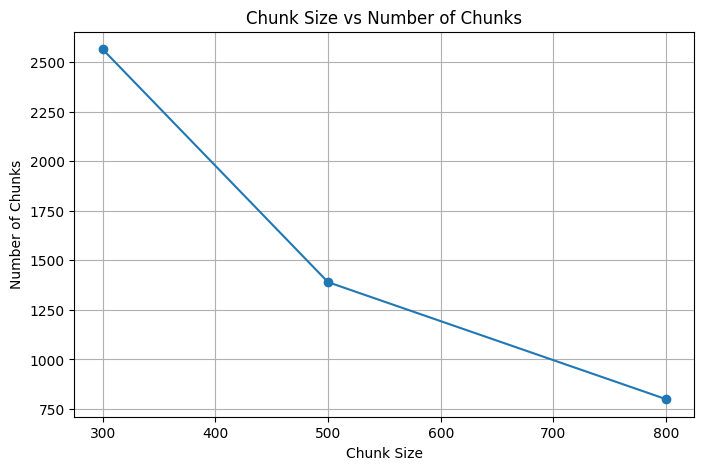

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    chunk_results_df["chunk_size"],
    chunk_results_df["num_chunks"],
    marker="o"
)

plt.xlabel("Chunk Size")
plt.ylabel("Number of Chunks")
plt.title("Chunk Size vs Number of Chunks")

plt.grid(True)

plt.show()

In [102]:
eval_df = pd.read_csv("/kaggle/working/evaluation_dataset.csv")

experiment_questions = eval_df["question"].tolist()

print("Questions:", len(experiment_questions))

Questions: 25


In [103]:
from bert_score import score

In [104]:
def rag_answer(
    query,
    chunk_df,
    index,
    top_k_retrieval=30,
    top_k_rerank=3
):

    # Query Embedding
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    )

    # FAISS Retrieval
    distances, indices = index.search(
        query_embedding,
        top_k_retrieval
    )

    candidate_chunks = [
        chunk_df.iloc[idx]["chunk_text"]
        for idx in indices[0]
    ]

    # Cross Encoder Re-ranking
    pairs = [
        [query, chunk]
        for chunk in candidate_chunks
    ]

    rerank_scores = reranker.predict(pairs)

    reranked_results = sorted(
        zip(candidate_chunks, rerank_scores),
        key=lambda x: x[1],
        reverse=True
    )

    top_chunks = [
        chunk
        for chunk, score in reranked_results[:top_k_rerank]
    ]

    # Context Construction
    context = "\n\n".join(top_chunks)

    # Prompt
    prompt = f"""
    You are a robotics assistant.
    
    Answer the question using ONLY the provided context.
    
    Provide:
    1. A direct answer in the first sentence.
    2. Additional details afterwards.
    
    If the answer cannot be found in the context, respond exactly:
    
    I could not find the answer in the provided documents.
    
    Context:
    {context}
    
    Question:
    {query}
    
    Answer:
    """

    # Generation
    response = generator(
        prompt,
        max_new_tokens=150,
        do_sample=False
    )

    answer = response[0]["generated_text"]

    return answer

In [105]:
test_answer = rag_answer(
    "What is SLAM?",
    chunk_df,
    index
)

print(test_answer)

Token indices sequence length is longer than the specified maximum sequence length for this model (537 > 512). Running this sequence through the model will result in indexing errors
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



    You are a robotics assistant.
    
    Answer the question using ONLY the provided context.
    
    Provide:
    1. A direct answer in the first sentence.
    2. Additional details afterwards.
    
    If the answer cannot be found in the context, respond exactly:
    
    I could not find the answer in the provided documents.
    
    Context:
    Simultaneous localization and mapping (SLAM) is a process where a computer constructs or updates a map of an unknown environment while simultaneously keeping track of an entity's location within it. While this initially appears to be a chicken or the egg problem, there are several algorithms known to solve it in, at least approximately, tractable time for certain environments. Popular approximate solution methods include the particle filter, extended Kalman filter, covariance intersection, and GraphSLAM. SLAM algorithms are based on concepts in computational geometry and computer vision, and are used in robot navigation, robotic mappin

In [106]:
chunk_experiment_results = []
experiment_outputs = []

In [ ]:
for size in chunk_sizes:

    print(f"\nRunning Chunk Size = {size}")

    chunk_df = create_chunks(
        corpus_df,
        chunk_size=size,
        overlap=100
    )

    embeddings = generate_embeddings(chunk_df)

    index = build_faiss(embeddings)

    predictions = []
    references = []

    for question in experiment_questions:

        answer = rag_answer(
            question,
            chunk_df,
            index
        )

        reference = eval_df[
            eval_df["question"] == question
        ]["ground_truth"].values[0]

        predictions.append(answer)
        references.append(reference)

        # Save individual prediction
        experiment_outputs.append({
            "chunk_size": size,
            "question": question,
            "ground_truth": reference,
            "generated_answer": answer
        })

    P, R, F1 = score(
        predictions,
        references,
        lang="en"
    )

    bert_f1 = F1.mean().item()

    # Save summary result
    chunk_experiment_results.append({
        "chunk_size": size,
        "num_chunks": len(chunk_df),
        "bertscore_f1": bert_f1
    })

    print("BERTScore:", bert_f1)


Running Chunk Size = 300
Total Chunks: 2566


Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Embedding Shape: (2566, 384)


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

Embedding Shape: (799, 384)


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore: 0.8291807770729065


In [ ]:
experiment_outputs.append({
    "chunk_size": size,
    "question": question,
    "prediction": answer,
    "ground_truth": reference
})

In [ ]:
chunk_experiment_df = pd.DataFrame(
    chunk_experiment_results
)

experiment_outputs_df = pd.DataFrame(
    experiment_outputs
)

chunk_experiment_df

In [ ]:
chunk_experiment_df.to_csv(
    "chunk_size_experiment.csv",
    index=False
)

experiment_outputs_df.to_csv(
    "chunk_size_predictions.csv",
    index=False
)

print("Saved Successfully")

**PHASE 11: VISUALIZATION**

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    chunk_experiment_df["chunk_size"].astype(str),
    chunk_experiment_df["num_chunks"]
)

plt.title("Chunk Size vs Number of Chunks")
plt.xlabel("Chunk Size")
plt.ylabel("Number of Chunks")

plt.tight_layout()

plt.savefig(
    "chunk_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    chunk_experiment_df["chunk_size"],
    chunk_experiment_df["bertscore_f1"],
    marker="o"
)

plt.title("Chunk Size vs BERTScore")
plt.xlabel("Chunk Size")
plt.ylabel("BERTScore F1")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "chunk_size_vs_bertscore.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
metrics_df = pd.DataFrame({
    "Metric": [
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "BLEU",
        "BERTScore-F1"
    ],
    "Score": [
        0.379709,
        0.254842,
        0.341713,
        0.175035,
        0.885170
    ]
})

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    metrics_df["Metric"],
    metrics_df["Score"]
)

plt.title("Evaluation Metrics")
plt.ylabel("Score")

plt.tight_layout()

plt.savefig(
    "metrics_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os

for file in os.listdir():
    if file.endswith(".png"):
        print(file)

**PHASE 12: DOCUMENTATION**

Key Learnings
1. Chunking

The quality of retrieval depends heavily on how documents are split into chunks. Smaller chunks provide more focused information but increase the total number of chunks, while larger chunks preserve more context but may introduce irrelevant information. Through experimentation with chunk sizes of 300, 500, and 800 characters, larger chunks achieved slightly better BERTScore performance because they retained more contextual information during retrieval and generation.

2. Embeddings

Sentence embeddings enabled semantic search beyond simple keyword matching. Using the all-MiniLM-L6-v2 model, each text chunk was converted into a 384-dimensional vector representation. Similar concepts such as "SLAM", "localization", and "mapping" could be matched even when exact query terms were not present, demonstrating the effectiveness of dense vector representations for knowledge retrieval.

3. Retrieval

FAISS provided efficient similarity search over hundreds of document chunks. Initial retrieval produced relevant results for most robotics-related queries. Introducing a Cross-Encoder re-ranker improved retrieval quality by re-evaluating candidate chunks with a deeper semantic comparison between the query and retrieved documents. Re-ranking consistently produced more accurate and focused context for answer generation.

4. Generation

The FLAN-T5 model successfully generated answers using the retrieved context. Prompt design played an important role in answer quality. Explicit instructions to use only the provided context reduced hallucinations and improved factual consistency. The generation stage demonstrated how retrieved knowledge can be transformed into natural-language responses for end users.

5. Evaluation

Multiple evaluation metrics were used to assess system performance. ROUGE and BLEU measured lexical overlap between generated answers and reference answers, while BERTScore evaluated semantic similarity using contextual embeddings. BERTScore produced the highest scores because it captures semantic meaning rather than exact word matching. The evaluation process highlighted the importance of using multiple complementary metrics when assessing Retrieval-Augmented Generation systems.

Overall Conclusion

This project demonstrated the complete Retrieval-Augmented Generation (RAG) pipeline, including data collection, document preprocessing, chunking, embedding generation, vector search with FAISS, retrieval re-ranking, answer generation using FLAN-T5, and quantitative evaluation. The experiments showed that retrieval quality, chunking strategy, and prompt design have a significant impact on final answer performance. The resulting system can answer robotics-related questions using information extracted from a custom robotics knowledge base built from Wikipedia articles.

## Note on RAGAS Evaluation

RAGAS was initially planned as part of the evaluation framework to measure retrieval-specific metrics such as Faithfulness, Answer Relevancy, Context Precision, and Context Recall. However, it was not included in the final implementation due to dependency compatibility issues encountered within the Kaggle environment.

The project was developed using Python 3.12 and the latest versions of LangChain, Sentence Transformers, and related libraries. RAGAS required older versions of several LangChain components and additional dependencies that conflicted with the versions needed for the retrieval and embedding pipeline. Multiple dependency configurations were tested, but they introduced import errors and package conflicts involving LangChain Community, NumPy, SciPy, Scikit-Learn, and Sentence Transformers.

To maintain a stable and reproducible end-to-end pipeline, evaluation was performed using ROUGE, BLEU, and BERTScore metrics instead. These metrics provided reliable quantitative assessment of answer quality while preserving compatibility with the project environment.

Future work may include implementing RAGAS in a dedicated environment with fully compatible dependency versions to enable retrieval-specific evaluation and comparison against traditional NLP metrics.
